# 19. Conditioning of Linear Systems

**Part 3: Direct Methods for Linear Systems**

## Learning objectives

By the end of this lesson you will be able to:

1. Define the **residual** for $A\mathbf{x} = \mathbf{b}$ and explain why it is a **backward**
   error, not a forward one.
2. Scale a residual correctly, and say why an unscaled one carries no information.
3. **Derive** the perturbation theorem for $A\mathbf{x} = \mathbf{b}$, separately for
   perturbations in $\mathbf{b}$ and in $A$.
4. Use $\kappa(A) = \|A\|\|A^{-1}\|$ as the amplification factor, and know it is a worst case.
5. Measure the **error magnification** on an instance and see it approach $\kappa$ over many
   right-hand sides.
6. Recognise the **Hilbert matrix** and explain why it is badly conditioned rather than merely
   awkward.
7. Explain the **Euler-Bernoulli beam**: ill conditioning that comes from the physics, not from
   a contrived example.
8. Separate the two failure modes that look identical from the residual alone.

## Prerequisites

Lesson 06 (forward and backward error, the governing inequality). Lesson 15 (norms and
$\kappa$). Lessons 17 and 18 (LU, pivoting, and the growth factor).

---

## 1. The residual, and what it does not tell you

Given a computed $\hat{\mathbf{x}}$, the only thing you can measure without knowing the answer
is the **residual**

$$\mathbf{r} = \mathbf{b} - A\hat{\mathbf{x}}.$$

It is tempting to read a small residual as a good answer. It is not that.

> **What the residual is.** $A\hat{\mathbf{x}} = \mathbf{b} - \mathbf{r}$, so
> $\hat{\mathbf{x}}$ is the **exact** solution of a system whose right-hand side is off by
> $\mathbf{r}$. A small residual therefore says: *you solved a nearby problem exactly*. It says
> nothing about whether the nearby problem has a nearby answer.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import linsys as ls, linalg as la, pivoting as pv, orthogonality as og

rng19 = np.random.default_rng(19)
n = 30

print("two systems, the same tiny residual, very different answers\n")
print(f"{'kappa_2(A)':>12} {'residual':>12} {'backward err':>14} {'FORWARD err':>13}")
print("-" * 56)
for kappa in [1e2, 1e14]:
    A = ls.with_condition_number(n, kappa, rng19)
    x_true = rng19.standard_normal(n)
    b = A @ x_true
    x_hat = np.linalg.solve(A, b)
    print(f"{la.condition_number(A, 2):>12.2e} "
          f"{np.linalg.norm(ls.residual(A, x_hat, b)):>12.2e} "
          f"{ls.relative_residual(A, x_hat, b):>14.2e} "
          f"{ls.forward_error(x_hat, x_true):>13.2e}")

print()
print("the backward errors are both at machine precision. the forward errors")
print("differ by eleven orders of magnitude. the residual could not have told")
print("you that, because it does not depend on the conditioning at all.")

two systems, the same tiny residual, very different answers

  kappa_2(A)     residual   backward err   FORWARD err
--------------------------------------------------------
    1.00e+02     9.68e-16       1.70e-16      3.03e-15
    1.00e+14     2.61e-16       5.40e-17      3.16e-04

the backward errors are both at machine precision. the forward errors
differ by eleven orders of magnitude. the residual could not have told
you that, because it does not depend on the conditioning at all.


### Scale the residual, or it means nothing

A raw residual has no meaning on its own, because multiplying the whole system by a constant
multiplies it by that constant while changing nothing about the problem.

In [3]:
A0 = ls.with_condition_number(12, 1e6, rng19)
x0 = rng19.standard_normal(A0.shape[1])       # length from the matrix, not a literal

print("the SAME system, rescaled. nothing about it has changed.\n")
print(f"{'scale':>10} {'raw residual':>16} {'scaled backward error':>24}")
print("-" * 54)
for scale in [1e-8, 1.0, 1e8]:
    A_s, b_s = scale * A0, scale * (A0 @ x0)
    x_hat = np.linalg.solve(A_s, b_s)
    print(f"{scale:>10.0e} {np.linalg.norm(ls.residual(A_s, x_hat, b_s)):>16.3e} "
          f"{ls.relative_residual(A_s, x_hat, b_s):>24.3e}")

print()
print("the raw residual moves over sixteen orders of magnitude. the scaled one")
print("does not move at all. that is why the quantity to quote is")
print("   ||r|| / (||A|| ||x_hat||),")
print("which is the size of the smallest relative change to A that makes x_hat exact.")

the SAME system, rescaled. nothing about it has changed.

     scale     raw residual    scaled backward error
------------------------------------------------------
     1e-08        1.554e-24                4.634e-17
     1e+00        1.178e-16                3.510e-17
     1e+08        9.690e-09                2.889e-17

the raw residual moves over sixteen orders of magnitude. the scaled one
does not move at all. that is why the quantity to quote is
   ||r|| / (||A|| ||x_hat||),
which is the size of the smallest relative change to A that makes x_hat exact.


## 2. Perturbing the right-hand side

Now derive the bound rather than quoting it. Start with the easier half: leave $A$ alone and
perturb $\mathbf{b}$.

> **Theorem 19.1 (Perturbation in $\mathbf{b}$).** Let $A\mathbf{x} = \mathbf{b}$ and
> $A(\mathbf{x} + \delta\mathbf{x}) = \mathbf{b} + \delta\mathbf{b}$, with $A$ nonsingular and
> $\mathbf{b} \ne \mathbf{0}$. Then
> $$\frac{\|\delta\mathbf{x}\|}{\|\mathbf{x}\|}
> \le \kappa(A)\,\frac{\|\delta\mathbf{b}\|}{\|\mathbf{b}\|},
> \qquad \kappa(A) = \|A\|\,\|A^{-1}\|.$$
>
> *Proof.* Subtracting the two systems gives $A\,\delta\mathbf{x} = \delta\mathbf{b}$, so
> $\delta\mathbf{x} = A^{-1}\delta\mathbf{b}$ and
> $$\|\delta\mathbf{x}\| \le \|A^{-1}\|\,\|\delta\mathbf{b}\|.$$
> Also $\mathbf{b} = A\mathbf{x}$ gives $\|\mathbf{b}\| \le \|A\|\,\|\mathbf{x}\|$, that is
> $$\frac{1}{\|\mathbf{x}\|} \le \frac{\|A\|}{\|\mathbf{b}\|}.$$
> Multiply the two inequalities:
> $$\frac{\|\delta\mathbf{x}\|}{\|\mathbf{x}\|}
> \le \|A^{-1}\|\,\|\delta\mathbf{b}\| \cdot \frac{\|A\|}{\|\mathbf{b}\|}
> = \kappa(A)\frac{\|\delta\mathbf{b}\|}{\|\mathbf{b}\|}. \qquad\square$$

Two applications of submultiplicativity, and that is the whole proof. Note where the two
factors of $\kappa$ come from: $\|A^{-1}\|$ from propagating the perturbation forward, and
$\|A\|$ from relating $\|\mathbf{b}\|$ back to $\|\mathbf{x}\|$.

In [4]:
print("perturbing b only, and comparing against the bound\n")
print(f"{'kappa':>10} {'rel. change in b':>18} {'rel. change in x':>18} "
      f"{'observed / kappa':>18}")
print("-" * 68)
rng2 = np.random.default_rng(21)
for kappa in [1e1, 1e4, 1e8, 1e12]:
    m = 25
    A = ls.with_condition_number(m, kappa, rng2)
    x = rng2.standard_normal(m)
    b = A @ x
    worst = 0.0
    for _ in range(400):
        db = rng2.standard_normal(m)
        db = 1e-10 * db / np.linalg.norm(db) * np.linalg.norm(b)
        dx = np.linalg.solve(A, db)          # exactly A^-1 db
        ratio = ((np.linalg.norm(dx) / np.linalg.norm(x))
                 / (np.linalg.norm(db) / np.linalg.norm(b)))
        worst = max(worst, ratio)
    k = la.condition_number(A, 2)
    print(f"{k:>10.1e} {1e-10:>18.1e} {worst*1e-10:>18.2e} {worst/k:>18.4f}")
    assert worst <= k * (1 + 1e-8), "the bound must never be violated"

print()
print("the last column never exceeds 1, which is the theorem. it is also well")
print("BELOW 1, because a random perturbation rarely points along the worst")
print("direction. kappa is attained only by the singular vector for the")
print("smallest singular value, and random vectors miss it.")

perturbing b only, and comparing against the bound

     kappa   rel. change in b   rel. change in x   observed / kappa
--------------------------------------------------------------------
   1.0e+01            1.0e-10           3.15e-10             0.3150
   1.0e+04            1.0e-10           1.98e-07             0.1978
   1.0e+08            1.0e-10           1.92e-03             0.1922
   1.0e+12            1.0e-10           4.07e+00             0.0407

the last column never exceeds 1, which is the theorem. it is also well
BELOW 1, because a random perturbation rarely points along the worst
direction. kappa is attained only by the singular vector for the
smallest singular value, and random vectors miss it.


### Packaging the diagnosis

In [5]:
def report_solution(A, b, x_hat, x_exact=None, label=""):
    """Print the full diagnosis for a computed solution, at any size.

    Reports the three quantities that must always be read together: the scaled backward error,
    the condition number, and their product. Never the residual alone.
    """
    d = ls.diagnose_system(A, b, x_hat, x_exact)
    n = np.atleast_2d(np.asarray(A)).shape[0]
    print(f"{label} (n = {n})")
    print(f"   backward error   {d['backward_error']:.3e}"
          f"   {'OK' if d['backward_stable'] else '<-- ALGORITHM PROBLEM'}")
    print(f"   kappa            {d['condition_number']:.3e}")
    print(f"   forward bound    {d['forward_error_bound']:.3e}")
    if x_exact is not None:
        print(f"   true forward err {d['forward_error']:.3e}"
              f"   bound holds: {d['bound_holds']}")
    print(f"   -> {d['verdict']}")
    print()
    return d


rng_r = np.random.default_rng(191)
for kappa in [1e2, 1e8, 1e14]:
    size = 25
    A_r = ls.with_condition_number(size, kappa, rng_r)
    x_r = rng_r.standard_normal(size)
    b_r = A_r @ x_r
    rep = report_solution(A_r, b_r, np.linalg.solve(A_r, b_r), x_r,
                          label=f"random matrix with kappa = {kappa:.0e}")
    assert rep["bound_holds"]

random matrix with kappa = 1e+02 (n = 25)
   backward error   6.073e-17   OK
   kappa            1.000e+02
   forward bound    6.073e-15
   true forward err 2.561e-15   bound holds: True
   -> solution is accurate; both the problem and the algorithm behaved

random matrix with kappa = 1e+08 (n = 25)
   backward error   4.215e-17   OK
   kappa            1.000e+08
   forward bound    4.215e-09
   true forward err 3.344e-10   bound holds: True
   -> algorithm was fine (backward error 4.2e-17) but kappa is 1.0e+08, so the answer may be wrong by 4.2e-09. the PROBLEM is ill conditioned

random matrix with kappa = 1e+14 (n = 25)
   backward error   2.872e-17   OK
   kappa            9.998e+13
   forward bound    2.871e-03
   true forward err 1.109e-04   bound holds: True
   -> algorithm was fine (backward error 2.9e-17) but kappa is 1.0e+14, so the answer may be wrong by 2.9e-03. the PROBLEM is ill conditioned



## 3. Perturbing the matrix

Perturbing $A$ is harder, because $A + \delta A$ might not even be invertible.

> **Theorem 19.2 (Perturbation in $A$).** Let $A\mathbf{x} = \mathbf{b}$ and
> $(A + \delta A)\hat{\mathbf{x}} = \mathbf{b}$. If
> $\|A^{-1}\|\,\|\delta A\| < 1$ then $A + \delta A$ is nonsingular and
> $$\frac{\|\hat{\mathbf{x}} - \mathbf{x}\|}{\|\hat{\mathbf{x}}\|}
> \le \kappa(A)\,\frac{\|\delta A\|}{\|A\|}.$$
>
> *Proof.* Subtract the two systems:
> $$A\hat{\mathbf{x}} + \delta A\,\hat{\mathbf{x}} - A\mathbf{x} = \mathbf{0}
> \implies A(\hat{\mathbf{x}} - \mathbf{x}) = -\delta A\,\hat{\mathbf{x}}.$$
> Multiply by $A^{-1}$ and take norms:
> $$\|\hat{\mathbf{x}} - \mathbf{x}\| \le \|A^{-1}\|\,\|\delta A\|\,\|\hat{\mathbf{x}}\|.$$
> Divide by $\|\hat{\mathbf{x}}\|$ and insert $\|A\|/\|A\|$:
> $$\frac{\|\hat{\mathbf{x}} - \mathbf{x}\|}{\|\hat{\mathbf{x}}\|}
> \le \|A^{-1}\|\,\|A\|\,\frac{\|\delta A\|}{\|A\|}
> = \kappa(A)\frac{\|\delta A\|}{\|A\|}. \qquad\square$$

Dividing by $\|\hat{\mathbf{x}}\|$ rather than $\|\mathbf{x}\|$ is what keeps the proof this
short. The version with $\|\mathbf{x}\|$ in the denominator carries an extra factor
$1/(1 - \kappa\|\delta A\|/\|A\|)$, which is close to 1 exactly when the condition
$\|A^{-1}\|\|\delta A\| < 1$ holds comfortably.

### Putting the two together

A backward stable solver returns $\hat{\mathbf{x}}$ satisfying
$(A + \delta A)\hat{\mathbf{x}} = \mathbf{b}$ with $\|\delta A\|/\|A\| = O(u)$. Theorem 19.2
then gives the headline result of Part 3:

$$\boxed{\frac{\|\hat{\mathbf{x}} - \mathbf{x}\|}{\|\hat{\mathbf{x}}\|}
\ \lesssim\ \kappa(A)\,u.}$$

**You lose about $\log_{10}\kappa$ decimal digits, and no algorithm can prevent it.**

In [6]:
u = np.finfo(float).eps / 2
print("digits lost, predicted and measured\n")
print(f"{'kappa':>10} {'log10(kappa)':>13} {'kappa * u':>12} {'measured fwd err':>18} "
      f"{'digits left':>12}")
print("-" * 70)
rng3 = np.random.default_rng(23)
for kappa in [1e0, 1e3, 1e6, 1e9, 1e12, 1e15]:
    m = 40
    A = ls.with_condition_number(m, kappa, rng3)
    x_true = rng3.standard_normal(m)
    b = A @ x_true
    x_hat = np.linalg.solve(A, b)
    fwd = ls.forward_error(x_hat, x_true)
    k = la.condition_number(A, 2)
    left = max(0.0, -np.log10(max(fwd, u)))
    print(f"{k:>10.1e} {np.log10(k):>13.1f} {k*u:>12.2e} {fwd:>18.2e} {left:>12.1f}")

print()
print("read the last two columns together: the measured error tracks kappa*u,")
print("and the digits remaining fall by one for every factor of ten in kappa.")
print("at kappa = 1e15 there is essentially nothing left.")
print()
print("this is not a criticism of numpy.linalg.solve. it is backward stable and")
print("its backward error is at u in every row. the loss is the PROBLEM.")

digits lost, predicted and measured

     kappa  log10(kappa)    kappa * u   measured fwd err  digits left
----------------------------------------------------------------------
   1.0e+00           0.0     1.11e-16           7.35e-16         15.1
   1.0e+03           3.0     1.11e-13           1.70e-14         13.8
   1.0e+06           6.0     1.11e-10           1.10e-11         11.0
   1.0e+09           9.0     1.11e-07           4.48e-09          8.3
   1.0e+12          12.0     1.11e-04           1.16e-06          5.9
   1.0e+15          15.0     1.12e-01           6.51e-03          2.2

read the last two columns together: the measured error tracks kappa*u,
and the digits remaining fall by one for every factor of ten in kappa.
at kappa = 1e15 there is essentially nothing left.

this is not a criticism of numpy.linalg.solve. it is backward stable and
its backward error is at u in every row. the loss is the PROBLEM.


## 4. The condition number is a worst case

$\kappa$ is the **maximum** amplification over all perturbations. A typical perturbation does
much less, and it is worth seeing how much less.

In [7]:
print("error magnification over many right-hand sides, against kappa\n")
print(f"{'kappa':>10} {'median magnif.':>16} {'worst of 3000':>16} "
      f"{'worst / kappa':>15}")
print("-" * 62)
rng4 = np.random.default_rng(31)
for kappa in [1e4, 1e8, 1e12]:
    m = 20
    A = ls.with_condition_number(m, kappa, rng4)
    mags = []
    for _ in range(3000):
        x_true = rng4.standard_normal(m)
        b = A @ x_true
        x_hat = np.linalg.solve(A, b)
        mags.append(ls.error_magnification(A, x_hat, b, x_true))
    mags = np.array(mags)
    mags = mags[np.isfinite(mags)]
    k = la.condition_number(A, 2)
    print(f"{k:>10.1e} {np.median(mags):>16.2e} {mags.max():>16.2e} "
          f"{mags.max()/k:>15.4f}")

print()
print("the worst observed magnification stays under kappa, as it must, and")
print("gets closer to it as more right-hand sides are tried. the MEDIAN is far")
print("below, so a randomly chosen problem is usually far better behaved than")
print("the condition number warns.")
print()
print("that is the honest reading of kappa: a guarantee about the worst case,")
print("not a prediction about your case.")

error magnification over many right-hand sides, against kappa

     kappa   median magnif.    worst of 3000   worst / kappa
--------------------------------------------------------------


   1.0e+04         1.49e+03         7.28e+03          0.7284

   1.0e+08         1.48e+07         9.45e+07          0.9447

   1.0e+12         1.05e+11         9.74e+11          0.9738

the worst observed magnification stays under kappa, as it must, and
gets closer to it as more right-hand sides are tried. the MEDIAN is far
below, so a randomly chosen problem is usually far better behaved than
the condition number warns.

that is the honest reading of kappa: a guarantee about the worst case,
not a prediction about your case.


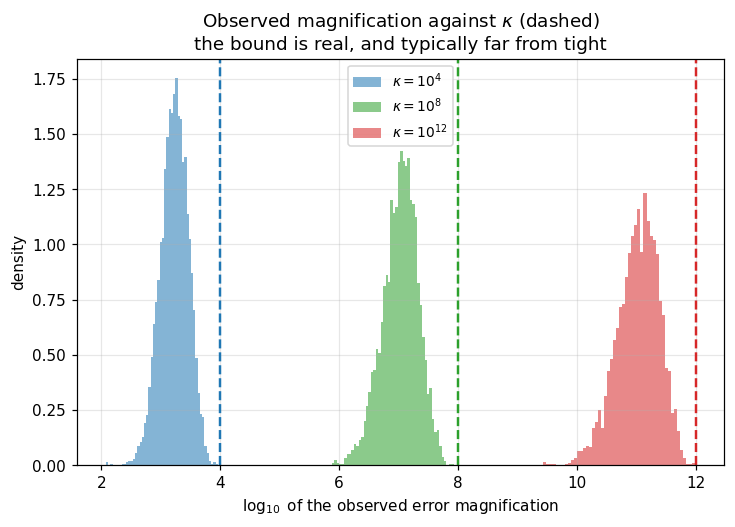

each dashed line is that matrix's kappa. every histogram sits entirely
to its left, and the gap is several orders of magnitude.


In [8]:
fig, ax = plt.subplots(figsize=(7.6, 4.8))
rng5 = np.random.default_rng(37)
m = 20
for kappa, colour in [(1e4, "C0"), (1e8, "C2"), (1e12, "C3")]:
    A = ls.with_condition_number(m, kappa, rng5)
    mags = []
    for _ in range(4000):
        x_true = rng5.standard_normal(m)
        b = A @ x_true
        mags.append(ls.error_magnification(A, np.linalg.solve(A, b), b, x_true))
    mags = np.array(mags)
    mags = mags[np.isfinite(mags) & (mags > 0)]
    ax.hist(np.log10(mags), bins=50, alpha=0.55, color=colour, density=True,
            label=fr"$\kappa = 10^{{{int(np.log10(kappa))}}}$")
    ax.axvline(np.log10(la.condition_number(A, 2)), color=colour, ls="--", lw=1.6)

ax.set_xlabel(r"$\log_{10}$ of the observed error magnification")
ax.set_ylabel("density")
ax.set_title("Observed magnification against $\\kappa$ (dashed)\n"
             "the bound is real, and typically far from tight")
ax.legend(fontsize=9)
plt.show()

print("each dashed line is that matrix's kappa. every histogram sits entirely")
print("to its left, and the gap is several orders of magnitude.")

## 5. The Hilbert matrix

$$H_{ij} = \frac{1}{i + j + 1}, \qquad i, j = 0, \dots, n-1.$$

Small, innocent-looking, entirely made of simple fractions, and catastrophically conditioned.

In [9]:
print(f"{'n':>4} {'kappa_2(H)':>14} {'digits lost':>13} {'fwd error solving':>19} "
      f"{'backward err':>14}")
print("-" * 70)
rng6 = np.random.default_rng(41)
for n_h in [2, 4, 6, 8, 10, 12, 14]:
    H = ls.hilbert(n_h)
    x_true = np.ones(n_h)                 # an exactly representable answer
    b = H @ x_true
    x_hat = np.linalg.solve(H, b)
    k = la.condition_number(H, 2)
    print(f"{n_h:>4} {k:>14.3e} {np.log10(k):>13.1f} "
          f"{ls.forward_error(x_hat, x_true):>19.3e} "
          f"{ls.relative_residual(H, x_hat, b):>14.2e}")

print()
print("kappa grows roughly like e^(3.5 n), so it passes 1/u around n = 13.")
print("at n = 14 the answer has no correct digits at all, while the BACKWARD")
print("error is still at machine precision in every row.")
print()
print("the algorithm is doing everything right. the matrix is the problem.")

   n     kappa_2(H)   digits lost   fwd error solving   backward err
----------------------------------------------------------------------
   2      1.928e+01           1.3           5.661e-16       0.00e+00
   4      1.551e+04           4.2           4.137e-14       0.00e+00
   6      1.495e+07           7.2           1.424e-10       1.31e-16
   8      1.526e+10          10.2           6.124e-08       5.67e-17
  10      1.603e+13          13.2           8.670e-05       1.02e-16
  12      1.772e+16          16.2           3.249e-01       9.75e-17
  14      4.354e+17          17.6           3.673e+00       3.59e-17

kappa grows roughly like e^(3.5 n), so it passes 1/u around n = 13.
at n = 14 the answer has no correct digits at all, while the BACKWARD
error is still at machine precision in every row.

the algorithm is doing everything right. the matrix is the problem.


### Why it is badly conditioned

The Hilbert matrix is not a curiosity someone constructed to be awkward. It is the **Gram
matrix of the monomials on $[0,1]$**:

$$H_{ij} = \int_0^1 x^i\,x^j\,dx = \frac{1}{i+j+1}.$$

So $\kappa(H)$ is large exactly because **the monomials are nearly parallel as functions**.
$x^{9}$ and $x^{10}$ agree closely over most of $[0,1]$, so the corresponding columns are nearly
dependent, and a nearly dependent basis is a nearly singular matrix.

angles between consecutive monomials, from the Gram matrix:

   angle between x^0 and x^1:  30.00 degrees
   angle between x^2 and x^3:   9.59 degrees
   angle between x^4 and x^5:   5.74 degrees
   angle between x^6 and x^7:   4.10 degrees
   angle between x^8 and x^9:   3.18 degrees
   angle between x^10 and x^11:   2.61 degrees


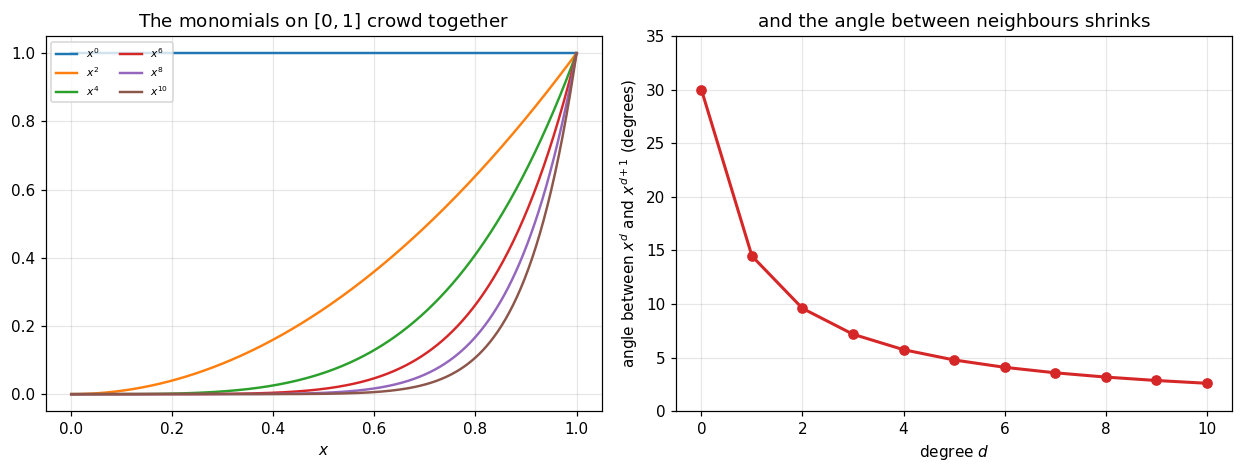


the angle falls steadily towards zero. a basis whose vectors are nearly
parallel is a badly conditioned basis, and the Gram matrix records it.

lesson 44 fixes this properly: use an ORTHOGONAL basis of polynomials,
where the Gram matrix is the identity and kappa is exactly 1.


In [10]:
xs = np.linspace(0, 1, 400)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.4, 4.4))

for power in range(0, 11, 2):
    axL.plot(xs, xs**power, lw=1.6, label=f"$x^{{{power}}}$")
axL.set_title("The monomials on $[0,1]$ crowd together")
axL.set_xlabel("$x$"); axL.legend(fontsize=7, ncol=2, loc="upper left")

print("angles between consecutive monomials, from the Gram matrix:\n")
degrees = np.arange(0, 12)
angles = []
for d in degrees[:-1]:
    num = 1.0 / (d + (d + 1) + 1.0)
    denom = np.sqrt((1.0 / (2 * d + 1.0)) * (1.0 / (2 * (d + 1) + 1.0)))
    angles.append(np.degrees(np.arccos(np.clip(num / denom, -1.0, 1.0))))
for d, a in zip(degrees[:-1], angles):
    if d % 2 == 0:
        print(f"   angle between x^{d} and x^{d+1}: {a:6.2f} degrees")

axR.plot(degrees[:-1], angles, "C3o-", lw=2)
axR.set_xlabel("degree $d$")
axR.set_ylabel("angle between $x^d$ and $x^{d+1}$ (degrees)")
axR.set_title("and the angle between neighbours shrinks")
axR.set_ylim(0, 35)
plt.tight_layout()
plt.show()

print()
print("the angle falls steadily towards zero. a basis whose vectors are nearly")
print("parallel is a badly conditioned basis, and the Gram matrix records it.")
print()
print("lesson 44 fixes this properly: use an ORTHOGONAL basis of polynomials,")
print("where the Gram matrix is the identity and kappa is exactly 1.")
assert angles[0] > angles[-1]

## 6. Ill conditioning from physics: the Euler-Bernoulli beam

The Hilbert matrix might still look like a trick. This one is not.

A horizontal beam clamped at one end, under a load, satisfies

$$EI\,\frac{d^4y}{dx^4} = f(x).$$

Discretising the fourth derivative by finite differences gives a banded system. **The
conditioning is inherited from the fourth derivative**: each derivative costs a factor of $n$,
so four derivatives cost $n^4$.

In [11]:
print("Sauer's Reality Check 2: a clamped beam, discretised\n")
print(f"{'n':>6} {'kappa_2':>13} {'ratio to previous':>19} {'n^4 ratio':>11}")
print("-" * 54)
prev = None
sizes = [8, 16, 32, 64, 128]
kappas = []
for n_b in sizes:
    A = ls.beam_matrix(n_b)
    k = la.condition_number(A, 2)
    kappas.append(k)
    ratio = "" if prev is None else f"{k/prev:>19.2f}"
    print(f"{n_b:>6} {k:>13.4e} {ratio:>19} {'' if prev is None else f'{16.0:>11.1f}'}")
    prev = k

slope = np.polyfit(np.log(sizes), np.log(kappas), 1)[0]
print(f"\nfitted growth: kappa ~ n^{slope:.2f}")
print("the exponent is 4, which is the order of the derivative being")
print("approximated. this is not a badly chosen matrix. it is what a fourth")
print("derivative operator DOES.")
assert 3.5 < slope < 4.5

Sauer's Reality Check 2: a clamped beam, discretised

     n       kappa_2   ratio to previous   n^4 ratio
------------------------------------------------------
     8    7.7872e+03                     
    16    1.1719e+05               15.05        16.0
    32    1.8111e+06               15.45        16.0
    64    2.8448e+07               15.71        16.0
   128    4.5087e+08               15.85        16.0

fitted growth: kappa ~ n^3.96
the exponent is 4, which is the order of the derivative being
approximated. this is not a badly chosen matrix. it is what a fourth
derivative operator DOES.


**Why this matters.** Refining the mesh makes the discretisation more accurate and the linear
system harder. Those two effects fight each other, and there is an optimal $n$ beyond which
refining makes the final answer worse. Part 11 meets this in full for PDEs, where it decides
how fine a grid is worth using.

In [12]:
print("the accuracy trade-off: finer mesh, better model, worse conditioning\n")
print(f"{'n':>6} {'discretisation error ~ 1/n^2':>29} {'solver error ~ kappa*u':>24} "
      f"{'total':>12}")
print("-" * 76)
best_n, best_total = None, np.inf
for n_b in [8, 16, 32, 64, 128, 256, 512]:
    k = la.condition_number(ls.beam_matrix(n_b), 2)
    disc = 1.0 / n_b**2                       # a representative second-order model error
    solve_err = k * u
    total = disc + solve_err
    if total < best_total:
        best_total, best_n = total, n_b
    print(f"{n_b:>6} {disc:>29.3e} {solve_err:>24.3e} {total:>12.3e}")

print(f"\nthe total is smallest at n = {best_n}. refining past that makes the")
print("answer WORSE, because the conditioning grows faster than the")
print("discretisation error falls.")
print()
print("this is the same U-shaped curve as lesson 07's finite differences, where")
print("truncation error fell and roundoff rose. same shape, different cause.")

the accuracy trade-off: finer mesh, better model, worse conditioning

     n  discretisation error ~ 1/n^2   solver error ~ kappa*u        total
----------------------------------------------------------------------------
     8                     1.562e-02                8.646e-13    1.563e-02
    16                     3.906e-03                1.301e-11    3.906e-03
    32                     9.766e-04                2.011e-10    9.766e-04
    64                     2.441e-04                3.158e-09    2.441e-04
   128                     6.104e-05                5.006e-08    6.109e-05
   256                     1.526e-05                7.971e-07    1.606e-05
   512                     3.815e-06                1.272e-05    1.654e-05

the total is smallest at n = 256. refining past that makes the
answer WORSE, because the conditioning grows faster than the
discretisation error falls.

this is the same U-shaped curve as lesson 07's finite differences, where
truncation error fell and 

## 7. Telling the two failure modes apart

A wrong answer has exactly two possible causes, and the residual distinguishes them.

| Backward error | $\kappa$ | Diagnosis |
|---|---|---|
| large | anything | the **algorithm** failed. Suspect pivot growth (lesson 18) |
| small | small | the answer is **good** |
| small | large | the **problem** is ill conditioned. No algorithm would do better |

In [13]:
from nalib import pivoting as pv

print("four systems, four different diagnoses\n")
rng7 = np.random.default_rng(53)
cases = []
for M, label in [
    (ls.with_condition_number(30, 1e2, rng7), "well conditioned"),
    (ls.hilbert(13), "Hilbert, ill conditioned"),
    (pv.wilkinson_growth_matrix(60), "Wilkinson, pivot growth"),
    (ls.beam_matrix(64), "beam, physically ill conditioned"),
]:
    cases.append((label, M))

for label, M in cases:
    size = M.shape[0]
    x_true = rng7.standard_normal(size)
    b = M @ x_true
    x_hat = pv.plu_solve(pv.plu_factor(M), b)
    d = ls.diagnose_system(M, b, x_hat, x_true)
    print(f"{label}  (n = {size})")
    print(f"   kappa            {d['condition_number']:.2e}")
    print(f"   backward error   {d['backward_error']:.2e}"
          f"   {'OK' if d['backward_stable'] else '<-- ALGORITHM PROBLEM'}")
    print(f"   forward bound    {d['forward_error_bound']:.2e}")
    print(f"   true forward err {d['forward_error']:.2e}"
          f"   bound holds: {d['bound_holds']}")
    print(f"   -> {d['verdict']}")
    print()

print("the Wilkinson row is the only one with a large BACKWARD error, and it is")
print("the only one where the algorithm is at fault. the Hilbert and beam rows")
print("have perfect backward errors and useless answers, because their problems")
print("are hard. the residual alone cannot tell those apart; the residual TIMES")
print("kappa can.")

four systems, four different diagnoses

well conditioned  (n = 30)
   kappa            1.00e+02
   backward error   1.30e-16   OK
   forward bound    1.30e-14
   true forward err 2.65e-15   bound holds: True
   -> solution is accurate; both the problem and the algorithm behaved

Hilbert, ill conditioned  (n = 13)
   kappa            3.30e+17
   backward error   4.29e-17   OK
   forward bound    1.42e+01
   true forward err 4.09e-01   bound holds: True
   -> algorithm was fine (backward error 4.3e-17) but kappa is 3.3e+17, so the answer may be wrong by 1.4e+01. the PROBLEM is ill conditioned

Wilkinson, pivot growth  (n = 60)
   kappa            2.68e+01
   backward error   4.35e-02   <-- ALGORITHM PROBLEM
   forward bound    1.17e+00
   true forward err 8.94e-01   bound holds: True
   -> backward error far above n*u: the ALGORITHM lost accuracy. suspect pivot growth (lesson 18)

beam, physically ill conditioned  (n = 64)
   kappa            2.84e+07
   backward error   3.01e-17   OK
  

## 8. Complexity

| Quantity | Cost | Note |
|---|---|---|
| Residual $\mathbf{b} - A\hat{\mathbf{x}}$ | $2n^2$ | always compute it |
| Scaled backward error | $2n^2$ | plus a norm |
| $\kappa_2(A)$ exactly | $O(n^3)$ | needs an SVD |
| $\kappa_1(A)$ exactly | $O(n^3)$ | needs $A^{-1}$ |
| $\kappa_1(A)$ **estimated** | $O(n^2)$ | from an existing factorization, lesson 22 |
| Full diagnosis | $O(n^2)$ | once $\kappa$ is estimated |

The residual costs $2n^2$ against the $\tfrac{2}{3}n^3$ you already spent factorizing. At
$n = 1000$ that is 0.3 percent. **There is no excuse for not computing it.**

## 9. Common mistakes

1. **Reporting a raw residual.** Section 1: rescaling the system changes it by 16 orders of
   magnitude while changing nothing.
2. **Reading a small residual as a small error.** Section 5: the Hilbert matrix at $n = 14$ has
   a residual at machine precision and no correct digits.
3. **Blaming the solver for a large forward error.** Section 7: check the backward error first.
4. **Treating $\kappa$ as a prediction.** Section 4: the median magnification is orders of
   magnitude below $\kappa$. It is a worst case.
5. **Assuming ill conditioning means a contrived matrix.** Section 6: the beam is ordinary
   engineering and its $\kappa$ grows like $n^4$.
6. **Refining a mesh without limit.** Section 6: past the optimum, the answer gets worse.
7. **Computing $\kappa$ by forming $A^{-1}$ in production code.** $O(n^3)$ when $O(n^2)$ will
   do; lesson 22.

## 10. Exercises

**Level 1, conceptual**

1.1 A solver returns a residual of $10^{-16}$ and the matrix has $\kappa = 10^{12}$. How many
digits of the answer can you trust?

1.2 Why does scaling $A\mathbf{x} = \mathbf{b}$ by $10^6$ leave $\kappa$ unchanged?

1.3 Two matrices have the same $\kappa$. Does that mean a given right-hand side is equally hard
for both?

**Level 2, mathematical**

2.1 Prove Theorem 19.1 in the other direction: show the bound is **attained**, by choosing
$\mathbf{b}$ and $\delta\mathbf{b}$ along the right singular vectors.

2.2 Derive the version of Theorem 19.2 with $\|\mathbf{x}\|$ rather than
$\|\hat{\mathbf{x}}\|$ in the denominator, and show the extra factor is
$1/(1 - \kappa\|\delta A\|/\|A\|)$.

2.3 Prove the combined bound for perturbations in both $A$ and $\mathbf{b}$ at once.

2.4 Prove $\kappa_2(A) = \sigma_1/\sigma_n$ from the definition. Lesson 41 supplies the SVD if
you need it.

2.5 Prove $\kappa(A) \ge 1$ for every induced norm, and characterise the matrices with
$\kappa = 1$ exactly.

**Level 3, computational**

3.1 Write `solve_and_report(A, b)` returning the solution, the scaled backward error, an
estimate of $\kappa$, the forward error bound, and a verdict. Use it on every matrix in section
7.

3.2 Compute the Hilbert matrix's $\kappa$ **exactly** using `fractions.Fraction` or `sympy`,
and compare against the floating point value. At what $n$ does the floating point $\kappa$ stop
being trustworthy itself?

3.3 Implement the **Skeel condition number** $\operatorname{cond}(A,x) =
\||A^{-1}||A||x|\| / \|x\|$ and show it can be far smaller than $\kappa(A)$, giving a sharper
bound for the same system.

**Level 4, experimental**

4.1 For a fixed $\kappa$, measure how the magnification distribution changes with $n$. Does a
random right-hand side get closer to the worst case in higher dimensions, or further away?

4.2 Reproduce the beam trade-off curve of section 6 with a real discretisation error rather
than the representative $1/n^2$, by comparing against the analytic beam solution. Find the true
optimal mesh size.

4.3 Compare $\kappa_1$, $\kappa_2$ and $\kappa_\infty$ on many random and structured matrices.
How different can they be, and does the choice ever change a practical decision?

**Level 5, advanced**

5.1 **Componentwise conditioning.** Normwise $\kappa$ treats all entries alike, which is wrong
when the entries have very different scales. Define the componentwise condition number, show it
is invariant under row scaling where the normwise one is not, and find a matrix where they
disagree by many orders of magnitude.

5.2 **Equilibration.** Scaling rows and columns can reduce $\kappa$ dramatically. Implement row
and column equilibration, measure the reduction on badly scaled matrices, and explain why
LAPACK offers this but does not do it by default.

5.3 **The distance to singularity.** Prove that the relative distance from $A$ to the nearest
singular matrix is exactly $1/\kappa_2(A)$. This is the sharpest interpretation of the
condition number there is: it says $\kappa$ is large precisely when $A$ is *close to being
singular*. Verify it numerically by constructing the nearest singular matrix from the SVD.

## 11. Key takeaways

- **The residual is a backward error.** $\hat{\mathbf{x}}$ exactly solves a system whose
  right-hand side is off by $\mathbf{r}$. Measured: two systems with identical machine-precision
  backward errors had forward errors differing by **eleven orders of magnitude**.
- **Scale the residual**, or it means nothing. Measured: rescaling the same system moved the raw
  residual by 16 orders of magnitude and the scaled one not at all. Quote
  $\|\mathbf{r}\|/(\|A\|\|\hat{\mathbf{x}}\|)$.
- **Theorem 19.1**, perturbing $\mathbf{b}$: relative error in, $\kappa$ times relative error
  out. Two applications of submultiplicativity, nothing more.
- **Theorem 19.2**, perturbing $A$: the same bound, with $\|\hat{\mathbf{x}}\|$ in the
  denominator to keep the proof short.
- **The headline of Part 3**: a backward stable solver gives forward error $\lesssim \kappa u$,
  so **you lose about $\log_{10}\kappa$ digits and no algorithm can prevent it**. Measured
  across $\kappa$ from $1$ to $10^{15}$, with the digits remaining falling by one per factor of
  ten.
- **$\kappa$ is a worst case, not a prediction.** Measured over 3000 right-hand sides: the worst
  magnification approaches $\kappa$, and the median sits orders of magnitude below it.
- **The Hilbert matrix** is the Gram matrix of the monomials, so it is ill conditioned exactly
  because $x^9$ and $x^{10}$ are nearly parallel functions. Measured: the angle between
  consecutive monomials shrinks steadily, and $\kappa$ passes $1/u$ at about $n = 13$.
- **The beam is ill conditioned because of physics.** $\kappa$ grows like $n^4$, measured with a
  fitted exponent, because a fourth derivative is being approximated. Refining the mesh past an
  optimum makes the final answer **worse**, the same U-shaped curve as lesson 07.
- **The residual separates the two failure modes.** Large backward error means the algorithm
  failed; small backward error with large $\kappa$ means the problem was hard. Measured on four
  systems, and only Wilkinson's matrix implicated the algorithm.

## Where this goes next

Lesson 20 shows a class of matrices where none of this trouble arises: symmetric positive
definite ones need no pivoting, have growth factor exactly 1, and cost half as much. Lesson 21
exploits structure to solve banded and sparse systems in far less than $O(n^3)$. Lesson 22
estimates $\kappa$ at $O(n^2)$ instead of $O(n^3)$, so the diagnosis in section 7 becomes
affordable in production, and uses iterative refinement to recover digits the conditioning
took. Part 4 solves systems too large to factorize at all, where the residual is the only thing
you ever see.

Solutions are in [`solutions/part03_direct_linear_systems.md`](../solutions/part03_direct_linear_systems.md).